# 01 — Exploratory Data Analysis

**Data sources used by this project**

| Source | Used for | In repo? |
|---|---|---|
| Roboflow *vietnamese-license-plate* (CC BY 4.0, see `dataset/data.yaml`) | YOLOv8 plate detection | No — download separately |
| Synthetic characters (`src/classifier.py`) | OCR training | Generated |
| Synthetic plates (`scripts/generate_synthetic_plates.py`) | End-to-end regression benchmark | Generated |
| `lpr_demo/input_images/` | Manual demo | 1 image |

> **Limitation:** real labelled plate images are not committed, so this EDA covers the synthetic training/benchmark data. Scores on synthetic data are an upper bound on real-world performance.

In [1]:
import sys, json, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.classifier import (
    CHAR_CLASSES, generate_synthetic_chars, generate_plate_style_synthetic_chars,
)
random.seed(42); np.random.seed(42)
plt.rcParams["figure.dpi"] = 90


## 1. Character classes
Vietnamese plates exclude I, J, O, Q, W (confusable with digits).

In [2]:
print(len(CHAR_CLASSES), 'classes:', CHAR_CLASSES)
print('digits:', sum(c.isdigit() for c in CHAR_CLASSES), 'letters:', sum(c.isalpha() for c in CHAR_CLASSES))

31 classes: 0123456789ABCDEFGHKLMNPRSTUVXYZ
digits: 10 letters: 21


## 2. Synthetic character data — class balance

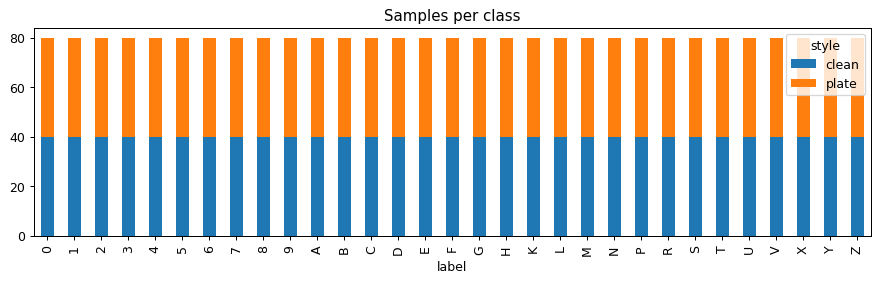

imbalance ratio (max/min): 1.0


In [3]:
x_clean, y_clean = generate_synthetic_chars(samples_per_class=40)
x_plate, y_plate = generate_plate_style_synthetic_chars(samples_per_class=40)
df = pd.DataFrame({
    'label': [CHAR_CLASSES[i] for i in np.concatenate([y_clean, y_plate])],
    'style': ['clean'] * len(y_clean) + ['plate'] * len(y_plate),
})
counts = df.groupby(['label', 'style']).size().unstack()
counts.plot.bar(stacked=True, figsize=(12, 3), title='Samples per class')
plt.show()
print('imbalance ratio (max/min):', counts.sum(1).max() / counts.sum(1).min())

## 3. Samples per class (clean vs plate-style)

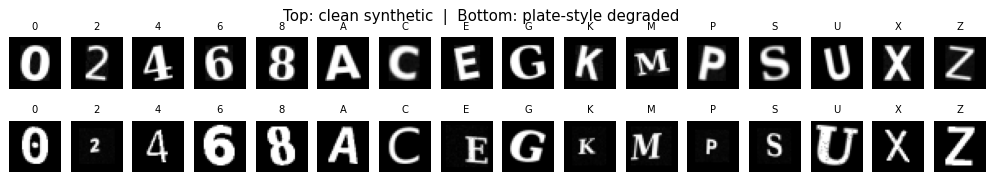

In [4]:
fig, axes = plt.subplots(2, 16, figsize=(14, 2.2))
for row, (x, y) in enumerate([(x_clean, y_clean), (x_plate, y_plate)]):
    for col, cls in enumerate(range(0, 31, 2)):
        idx = np.where(y == cls)[0][0]
        axes[row, col].imshow(x[idx], cmap='gray')
        axes[row, col].set_title(CHAR_CLASSES[cls], fontsize=8)
        axes[row, col].axis('off')
plt.suptitle('Top: clean synthetic  |  Bottom: plate-style degraded')
plt.show()

## 4. Pixel statistics and mean image per class

,style,mean_intensity,ink_ratio
0,clean,42.486723,0.162991
1,plate,35.548946,0.138752


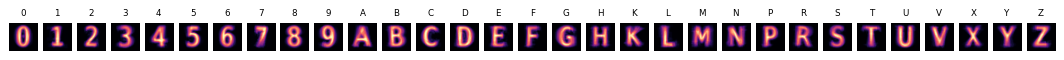

In [5]:
stats = pd.DataFrame({
    'style': ['clean', 'plate'],
    'mean_intensity': [x_clean.mean(), x_plate.mean()],
    'ink_ratio': [(x_clean > 127).mean(), (x_plate > 127).mean()],
})
display(stats)
fig, axes = plt.subplots(1, 31, figsize=(15, 1))
for cls in range(31):
    axes[cls].imshow(x_plate[y_plate == cls].mean(0), cmap='magma')
    axes[cls].set_title(CHAR_CLASSES[cls], fontsize=7); axes[cls].axis('off')
plt.show()

Mean images show how separable classes are: pairs such as **8/B**, **5/S**, **2/Z**, **0/D** have similar mean shapes — these are the confusions examined in the fairness analysis.

## 5. HOG features (324-d legacy vs 1764-d)

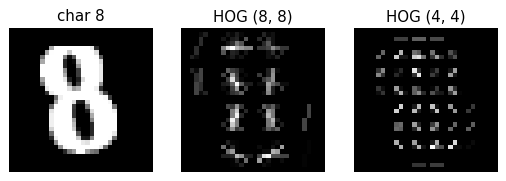

legacy dim: 324 | default dim: 1764


In [6]:
from skimage.feature import hog
from src.features import extract_hog_features, extract_hog_legacy_features
sample = x_plate[np.where(y_plate == CHAR_CLASSES.index('8'))[0][0]]
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))
axes[0].imshow(sample, cmap='gray'); axes[0].set_title('char 8')
for ax, ppc in zip(axes[1:], [(8, 8), (4, 4)]):
    _, vis = hog(sample / 255.0, pixels_per_cell=ppc, cells_per_block=(2, 2),
                 orientations=9, visualize=True)
    ax.imshow(vis, cmap='gray'); ax.set_title(f'HOG {ppc}')
for ax in axes: ax.axis('off')
plt.show()
print('legacy dim:', extract_hog_legacy_features([sample]).shape[1],
      '| default dim:', extract_hog_features([sample]).shape[1])

## 6. Synthetic plate benchmark

plate_type  plate_crop
1line       False          1
            True          19
2line       False          1
            True           9
Name: count, dtype: int64

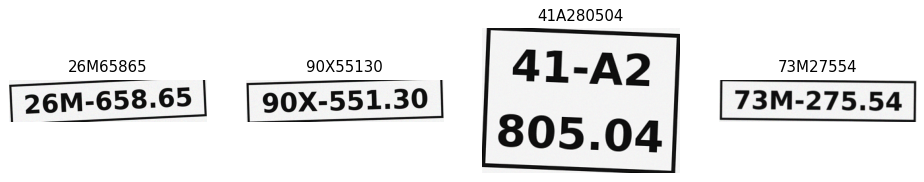

In [7]:
import tempfile
from scripts.generate_synthetic_plates import generate
bench_dir = Path(tempfile.mkdtemp())
manifest = pd.read_csv(generate(bench_dir, n=30, seed=2026, scene_fraction=0.3))
manifest['plate_type'] = np.where(manifest.label.str.len() == 9, '2line', '1line')
manifest['brightness'] = [cv2.imread(p, 0).mean() for p in manifest.image]
display(manifest.groupby(['plate_type', 'plate_crop']).size().rename('count'))
fig, axes = plt.subplots(1, 4, figsize=(13, 2.5))
for ax, (_, row) in zip(axes, manifest.head(4).iterrows()):
    ax.imshow(cv2.cvtColor(cv2.imread(row.image), cv2.COLOR_BGR2RGB))
    ax.set_title(row.label); ax.axis('off')
plt.show()

## 7. Demo image

shape: (761, 1280, 3) | mean brightness: 121.6


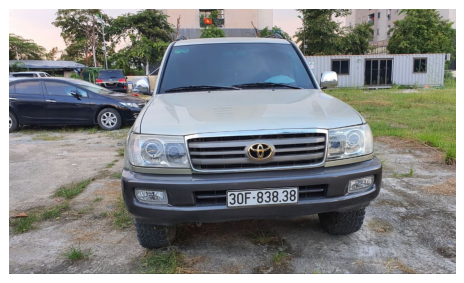

In [8]:
demo = PROJECT_ROOT / 'lpr_demo' / 'input_images' / 'test-my-oto.jpg'
img = cv2.cvtColor(cv2.imread(str(demo)), cv2.COLOR_BGR2RGB)
print('shape:', img.shape, '| mean brightness:', round(img.mean(), 1))
plt.imshow(img); plt.axis('off'); plt.show()

## Findings
- Classes are perfectly balanced by construction (imbalance ratio 1.0).
- Plate-style samples have a lower ink ratio than clean ones (≈13.9% vs 16.3%) and carry blur/erosion/noise/threshold artefacts, which is closer to segmented real glyphs.
- Visually similar pairs (8/B, 5/S, 2/Z, 0/D) are the main expected error source; format correction in `src/pipeline.py` exploits plate grammar (positions 0-1 digits, position 2 letter) to fix them.
- The demo/real images are much larger and darker than synthetic plates — the monitoring stack tracks input brightness/width drift.